## Гига М.Я. М8О-313Б-23

In [91]:
from typing import List, Tuple, cast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, KFold, cross_val_score
import os

Преобразуем dataframe, убираем nan, убираем некорректные значения

In [75]:
df: pd.DataFrame = pd.read_csv("./data/train.csv")
df = df.dropna()
df = cast(pd.DataFrame, df[df['RiskScore'].abs() < 200])
df["ApplicationDate"] = pd.to_datetime(df['ApplicationDate'])
df.sort_values(by="RiskScore") # pyright: ignore[reportUnusedExpression]

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
4700,1984-07-08,48.0,300000.0,850.0,8038.0,48.0,Divorced,1.0,Rent,263.0,...,5.0,Employed,High School,27.0,997849.0,0.088038,0.091271,200.511298,0.018540,14.841417
8434,2015-12-17,42.0,297719.0,773.0,11956.0,120.0,Single,0.0,Mortgage,266.0,...,10.0,Employed,High School,21.0,1070890.0,0.190456,0.220532,247.559837,0.020700,17.835591
4641,2013-03-28,32.0,300000.0,840.0,9565.0,36.0,Divorced,1.0,Own,512.0,...,1.0,Self-Employed,Associate,13.0,5543326.0,0.084565,0.087440,303.026120,0.032601,18.715380
6026,2003-11-13,38.0,300000.0,850.0,3198.0,48.0,Divorced,2.0,Mortgage,296.0,...,5.0,Employed,Bachelor,16.0,710138.0,0.083198,0.088396,79.339017,0.015014,18.990342
10931,1984-07-21,69.0,300000.0,850.0,9736.0,84.0,Single,2.0,Own,546.0,...,3.0,Employed,High School,44.0,181039.0,0.119736,0.134930,179.736912,0.029029,19.051625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,1990-11-12,71.0,22493.0,475.0,22006.0,48.0,Married,0.0,Mortgage,306.0,...,5.0,Self-Employed,High School,48.0,6109.0,0.289506,0.267068,750.759728,0.563781,93.781278
2151,1981-09-05,27.0,26139.0,522.0,39858.0,72.0,Married,1.0,Rent,409.0,...,6.0,Self-Employed,High School,2.0,10682.0,0.303858,0.308472,1220.946662,0.748283,94.098634
9030,2013-05-03,52.0,15000.0,395.0,21349.0,48.0,Divorced,4.0,Own,240.0,...,7.0,Employed,Bachelor,29.0,78094.0,0.328849,0.327562,803.289613,0.834632,96.082850
357,1999-04-09,28.0,15000.0,428.0,15097.0,84.0,Married,1.0,Mortgage,231.0,...,4.0,Employed,Bachelor,6.0,9105.0,0.336097,0.276618,408.191708,0.511353,96.172540


In [3]:
plt.figure(figsize=[10, df.shape[1] * 5])
for i, column in enumerate(df.columns):
    if column == "RiskScore":
        continue
    plt.subplot(round(df.shape[1] / 2), 2, i + 1)
    plt.scatter(df[column], df["RiskScore"])
    plt.title(column)

CreditScore                  -0.785425
MonthlyIncome                -0.770608
AnnualIncome                 -0.758480
TotalAssets                  -0.145735
NetWorth                     -0.144574
LengthOfCreditHistory        -0.056978
Experience                   -0.046446
Age                          -0.044183
NumberOfCreditInquiries      -0.016715
CheckingAccountBalance       -0.004531
NumberOfOpenCreditLines      -0.002806
SavingsAccountBalance         0.000328
ApplicationDate               0.003207
NumberOfDependents            0.007392
JobTenure                     0.012586
TotalLiabilities              0.016034
PaymentHistory                0.017636
MonthlyDebtPayments           0.018366
UtilityBillsPaymentHistory    0.022100
LoanDuration                  0.024928
PreviousLoanDefaults          0.054504
CreditCardUtilizationRate     0.055320
LoanAmount                    0.084978
DebtToIncomeRatio             0.110761
MonthlyLoanPayment            0.151459
BankruptcyHistory        

По графикам видно, что можно исключить JobTenure, EmploymentStatus,
EducationLevel, Experience, LengthOfCreditHistory,
PreviousLoanDefaults, PaymentHistory, BankruptcyHistory,
LoanPurpose, HomeOwnershipStatus, MaritalStatus, LoadDuration,
ApplicationDate

In [76]:
categoric = ["EducationLevel", "EmploymentStatus", 
             "HomeOwnershipStatus",
             "MaritalStatus", "LoanPurpose"]

df2 = df.copy()
le = LabelEncoder()
for col in categoric:
    df2[col] = le.fit_transform(df2[col])
correlation_matrix = df2.corr()
print(correlation_matrix.sort_values(by="RiskScore")["RiskScore"])

CreditScore                  -0.785425
MonthlyIncome                -0.770608
AnnualIncome                 -0.758480
TotalAssets                  -0.145735
NetWorth                     -0.144574
LengthOfCreditHistory        -0.056978
Experience                   -0.046446
Age                          -0.044183
NumberOfCreditInquiries      -0.016715
CheckingAccountBalance       -0.004531
NumberOfOpenCreditLines      -0.002806
SavingsAccountBalance         0.000328
MaritalStatus                 0.002486
ApplicationDate               0.003207
LoanPurpose                   0.004073
NumberOfDependents            0.007392
EducationLevel                0.008255
JobTenure                     0.012586
HomeOwnershipStatus           0.012678
TotalLiabilities              0.016034
PaymentHistory                0.017636
MonthlyDebtPayments           0.018366
UtilityBillsPaymentHistory    0.022100
LoanDuration                  0.024928
EmploymentStatus              0.050982
PreviousLoanDefaults     

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,1984-09-26,47.0,88686.0,648.0,5472.0,12.0,Divorced,2.0,Rent,98.0,...,4.0,Employed,Bachelor,23.0,121698.0,0.156472,0.164928,497.756143,0.080611,41.553066
11011,1980-01-15,39.0,300000.0,850.0,7721.0,72.0,Divorced,5.0,Own,276.0,...,2.0,Employed,Associate,16.0,18607.0,0.107721,0.108596,146.407421,0.016896,28.051757
11012,2010-07-10,57.0,300000.0,850.0,14756.0,48.0,Married,2.0,Own,620.0,...,4.0,Employed,Associate,38.0,167544.0,0.094756,0.106387,378.792448,0.039952,32.440586
11013,2003-10-22,28.0,15000.0,300.0,51361.0,96.0,Single,1.0,Own,696.0,...,3.0,Employed,Bachelor,5.0,116879.0,0.446361,0.401087,1793.042130,1.991234,67.673170


In [114]:
def KTest(X, y) -> Tuple[LinearRegression, List[float]]:
    scores = []
    model_best = LinearRegression(fit_intercept=False)
    max_score = 1000

    cv = KFold(n_splits=10, shuffle=True)
    for train_index, test_index in cv.split(X_ohe):
        model = LinearRegression(fit_intercept=False)
        X_train, X_test, y_train, y_test = X[train_index], X[test_index], y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append(mean_squared_error(y_test, y_pred))
        if scores[-1] < max_score:
            model_best = model
            max_score = scores[-1]
    return model_best, scores


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    selected = ["CreditScore", "MonthlyIncome", "BaseInterestRate", "TotalDebtToIncomeRatio"]
    res = cast(pd.DataFrame, df[selected + categoric])
    # repeats = ["AnnualIncome", "BaseInterestRate"]
    # res = df.drop(columns=repeats)
    return res


y = df['RiskScore']
X = df.drop(columns=['RiskScore'])
X = preprocess(X)
enc = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_ohe = enc.fit_transform(X)


model, scores = KTest(X_ohe, y)
scores

# model.fit(X_train, y_train)
# print("fitted model")

[94.03424538981527,
 83.93764124286768,
 94.49481746503528,
 86.6698115999545,
 89.04743417383163,
 88.04216839174657,
 86.45359218552463,
 82.08949462175231,
 85.81459625380363,
 89.17224999581353]

In [115]:
# X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.1, random_state=1)
#
y_pred = model.predict(X_ohe)
print(f"MSE  = {mean_squared_error(y, y_pred)}")
print(f"MAE  = {mean_absolute_error(y, y_pred)}")
print(f"MAPE = {mean_absolute_percentage_error(y, y_pred)}")
print(f"R^2  = {r2_score(y, y_pred)}")

MSE  = 8.203083959842733
MAE  = 0.6843463003199468
MAPE = 0.015794798543711578
R^2  = 0.9724487191795088


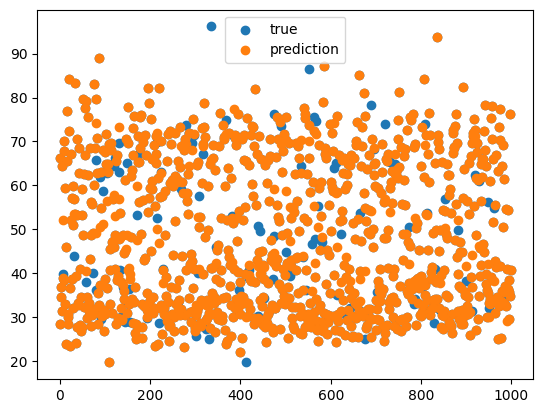

In [117]:
plt.subplot()
n = 1000
plt.scatter(np.arange(n), y[:n], label="true")
plt.scatter(np.arange(n), y_pred[:n], label="prediction")
plt.legend()

In [119]:
path = "./out.csv"
X_valid = pd.read_csv("./data/test.csv")
X_valid = X_valid.drop(columns=["ID"])
X_valid = preprocess(X_valid)
X_valid = enc.transform(X_valid)
print("prepared")
y_valid = model.predict(X_valid)
res = pd.DataFrame()
res["ID"] = np.arange(len(y_valid))
res["RiskScore"] = y_valid 
res.set_index("ID", inplace=True)

os.remove("./out.csv")
res.to_csv("./out.csv")
print("written")

prepared
written
